In [1]:
# =============================================================================
# CosmicWatch  —  Temperature-dependent dark-current analysis
# =============================================================================
# Data files : FileM034–039.txt  (tab-separated CosmicWatch format)
# Schedule   : Cosmic Watch Times - Sheet1.csv
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path

# --- Paths and global style --------------------------------------------------
DATA_DIR = Path('/home/aditya/code/jlab/cosmic_watch')
SCHEDULE = DATA_DIR / 'Cosmic Watch Times - Sheet1.csv'
plt.style.use(DATA_DIR / 'jlab.mplstyle')

# Consistent colour palette and trial labels used across every plot.
FILE_COLORS = {
    'FileM039.txt': 'tomato',
    'FileM034.txt': 'steelblue',
    'FileM036.txt': 'seagreen',
    'FileM037.txt': 'mediumpurple',
    'FileM038.txt': 'darkorange',
}

# Trial labels (chronological / temperature order).
FILE_LABELS = {
    'FileM039.txt': 'Trial 1',
    'FileM034.txt': 'Trial 2',
    'FileM036.txt': 'Trial 3',
    'FileM037.txt': 'Trial 4',
    'FileM038.txt': 'Trial 5',
}

# =============================================================================
# Time utilities
# =============================================================================

def parse_wall_time(s):
    """'HH:MM' or 'HH:MM:SS' wall-clock string → total seconds."""
    parts = s.strip().split(':')
    total = int(parts[0]) * 3600 + int(parts[1]) * 60
    if len(parts) == 3:
        total += int(parts[2])
    return total

def parse_device_time(s):
    """'H:MM:SS' device elapsed-time string → total seconds."""
    parts = s.strip().split(':')
    return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])

# =============================================================================
# File I/O
# =============================================================================

def load_data_file(filename):
    """Read one CosmicWatch tab-separated data file into a DataFrame.

    Columns returned:
      event, device_s, timestamp_ms, sipm_mv, temp, pressure_pa, dead_time_us
    """
    rows = []
    with open(DATA_DIR / filename) as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.strip().split('\t')
            if len(parts) < 10:
                continue
            try:
                rows.append({
                    'event':        int(parts[0]),
                    'device_s':     parse_device_time(parts[1]),
                    'timestamp_ms': float(parts[3]),
                    'sipm_mv':      float(parts[6]),
                    'temp':         float(parts[7]),
                    'pressure_pa':  float(parts[8]),
                    'dead_time_us': float(parts[9]),
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows)

def load_schedule(csv_path):
    """Parse the experiment schedule from the CosmicWatch CSV spreadsheet.

    The spreadsheet uses inconsistent formatting (mixed capitalisation,
    typos in "Initial").  This state-machine parser recognises three row
    types:

      'File: ,MXXX,...'    — start of a new run block
      'Initial Time:,...'  — device-clock start time for this file
      'HH:MM,HH:MM,T,...'  — a stable-temperature measurement window

    Transition rows (e.g. T = "5 to 25") are silently skipped.

    Returns a list of dicts, each with:
      file    : str   — filename, e.g. 'FileM034.txt'
      initial : str   — device start-time string, e.g. '15:12:00'
      periods : list  — [(t1_str, t2_str, T_nominal_int), ...]
    """
    schedule = []
    current  = None

    with open(csv_path) as f:
        for raw in f:
            cols  = [c.strip() for c in raw.split(',')]
            first = cols[0].lower()

            if first.startswith('file'):
                if current is not None:
                    schedule.append(current)
                current = {'file': f'File{cols[1]}.txt',
                           'initial': None, 'periods': []}

            elif current is not None and ('initial' in first or 'intial' in first):
                # Handles "Initial Time:", "Initial time:", "Intial time"
                current['initial'] = cols[1]

            elif current is not None and cols[0] and cols[1] and cols[2]:
                # Data row — skip header ("Time 1, ...") and range entries ("5 to 25")
                try:
                    T_nom = int(cols[2])
                    current['periods'].append((cols[0], cols[1], T_nom))
                except ValueError:
                    pass

    if current is not None:
        schedule.append(current)
    return schedule

# =============================================================================
# Rate calculation
# =============================================================================

def rate_from_intervals(df):
    """Compute dead-time-corrected count rate and Poisson uncertainty.

    Live time = total elapsed time - cumulative dead time logged per event.

    Rate  = N / T_live
    Error = sqrt(N) / T_live  (Poisson counting uncertainty)

    Returns (rate_hz, rate_err_hz), or (nan, nan) for fewer than 2 events.
    """
    ts = df['timestamp_ms'].sort_values().values
    if len(ts) < 2:
        return np.nan, np.nan
    total_s = (ts[-1] - ts[0]) / 1000.0
    t_live  = total_s - df['dead_time_us'].sum() / 1e6
    return len(ts) / t_live, np.sqrt(len(ts)) / t_live

# =============================================================================
# Data extraction: stable measurement windows (driven by Sheet1 times)
# =============================================================================

def build_stable_windows(schedule):
    """Clip each file to its stable-temperature windows from the schedule.

    For each (file, period) entry the data are restricted to the device-time
    interval [t_start, t_end] (converted from wall-clock offsets) and the
    count rate is computed for that window.

    A simple cache avoids reading the same file more than once even when
    multiple periods share a file.

    Returns
    -------
    stable_subsets  : {T_nominal -> DataFrame}
    stable_file_map : {T_nominal -> filename}
    records         : list of per-window dicts (file, temp, n_events, rate_hz, rate_err)
    """
    stable_subsets  = {}
    stable_file_map = {}
    records         = []
    file_cache      = {}

    for entry in schedule:
        t0 = parse_wall_time(entry['initial'])
        if entry['file'] not in file_cache:
            file_cache[entry['file']] = load_data_file(entry['file'])
        df = file_cache[entry['file']]

        for t1_str, t2_str, T in entry['periods']:
            t1 = parse_wall_time(t1_str) - t0
            t2 = parse_wall_time(t2_str) - t0
            subset = df[(df['device_s'] >= t1) & (df['device_s'] <= t2)].copy()

            rate, err = rate_from_intervals(subset)
            stable_subsets[T]  = subset
            stable_file_map[T] = entry['file']
            records.append(dict(file=entry['file'], temp=T,
                                n_events=len(subset),
                                rate_hz=rate, rate_err=err))
            print(f"  {FILE_LABELS[entry['file']]}  T={T:>2} C  {len(subset):>4} events  "
                  f"rate = {rate:.4f} +/- {err:.4f} Hz")

    return stable_subsets, stable_file_map, records

def build_summary(records):
    """Aggregate per-window records into a temperature summary table.

    Multiple windows at the same nominal T are combined with
    inverse-variance weighting.  Returns a DataFrame with columns:
    temp, total_events, rate_hz, rate_err.
    """
    df = pd.DataFrame(records)
    return (
        df.groupby('temp')
        .apply(lambda g: pd.Series({
            'total_events': g['n_events'].sum(),
            'rate_hz':      np.average(g['rate_hz'], weights=1 / g['rate_err']**2),
            'rate_err':     1 / np.sqrt((1 / g['rate_err']**2).sum()),
        }), include_groups=False)
        .reset_index()
        .sort_values('temp')
    )

# =============================================================================
# Data extraction: CosmicWatch 1-degree temperature bins
# =============================================================================

def build_binned_rates(file_list):
    """Compute dead-time-corrected count rates binned by 1-degree temperature.

    Each inter-event interval dt_i is assigned to the 1-degree bin of the
    temperature reported by the *preceding* event.  The dead time of that
    same (preceding) event is subtracted from the bin's live time.

    Rate  = N_bin / T_live_bin        [Hz]
    Error = sqrt(N_bin) / T_live_bin

    Returns a DataFrame with columns: file, temp_bin, n_events, rate_hz, rate_err.
    """
    segments = []
    for fname in file_list:
        df = load_data_file(fname).sort_values('timestamp_ms').reset_index(drop=True)
        if len(df) < 2:
            continue
        intervals = pd.DataFrame({
            'dt_s':         np.diff(df['timestamp_ms'].values) / 1000.0,
            'temp_bin':     df['temp'].values[:-1].round().astype(int),
            'dead_time_us': df['dead_time_us'].values[:-1],
            'file':         fname,
        })
        segments.append(intervals)

    df_int = pd.concat(segments, ignore_index=True)
    return (
        df_int.groupby(['file', 'temp_bin'])
        .apply(lambda g: pd.Series({
            'n_events': len(g),
            'rate_hz':  len(g) / (g['dt_s'].sum() - g['dead_time_us'].sum() / 1e6),
            'rate_err': np.sqrt(len(g)) / (g['dt_s'].sum() - g['dead_time_us'].sum() / 1e6),
        }), include_groups=False)
        .reset_index()
        .sort_values(['file', 'temp_bin'])
    )

# =============================================================================
# Colour utility
# =============================================================================

def darken(color, factor=0.6):
    """Return a darkened version of a colour (for nominal-point outlines)."""
    r, g, b, a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, a)

# =============================================================================
# Execute: load schedule and build all shared datasets
# =============================================================================

schedule        = load_schedule(SCHEDULE)
all_files       = [entry['file'] for entry in schedule]

print('Stable measurement windows:')
stable_subsets, stable_file_map, records = build_stable_windows(schedule)

summary     = build_summary(records)
file_binned = build_binned_rates(all_files)

print('\n=== Nominal count rates by temperature ===')
print(summary.to_string(index=False))


Stable measurement windows:
  Trial 2  T=25 C   689 events  rate = 1.3459 +/- 0.0513 Hz
  Trial 2  T=30 C   496 events  rate = 1.2414 +/- 0.0557 Hz
  Trial 3  T=35 C   724 events  rate = 1.4103 +/- 0.0524 Hz
  Trial 3  T=40 C   508 events  rate = 1.2719 +/- 0.0564 Hz
  Trial 4  T=45 C   770 events  rate = 1.5015 +/- 0.0541 Hz
  Trial 4  T=50 C   838 events  rate = 1.6363 +/- 0.0565 Hz
  Trial 5  T=55 C  1423 events  rate = 2.7883 +/- 0.0739 Hz
  Trial 1  T= 8 C   408 events  rate = 1.4284 +/- 0.0707 Hz

=== Nominal count rates by temperature ===
 temp  total_events  rate_hz  rate_err
    8         408.0 1.428379  0.070715
   25         689.0 1.345945  0.051276
   30         496.0 1.241419  0.055741
   35         724.0 1.410314  0.052414
   40         508.0 1.271892  0.056431
   45         770.0 1.501459  0.054109
   50         838.0 1.636296  0.056525
   55        1423.0 2.788333  0.073917


In [ ]:
# =============================================================================
# Poisson Verification
# =============================================================================
# Bin each stable-window recording into BIN_S-second bins and compare the
# observed count distribution to a Poisson PMF with the same mean.
# A good match confirms that detector events are independent (Poisson process).
# =============================================================================

from scipy.stats import poisson

BIN_S = 10  # time-bin width for the count-distribution check (seconds)

def plot_poisson_panel(ax, T, subset):
    """Plot observed count histogram vs Poisson PMF for one temperature window.

    Parameters
    ----------
    ax     : matplotlib Axes to draw on
    T      : nominal temperature label (°C) — used only for the panel title
    subset : DataFrame with a 'timestamp_ms' column
    """
    ts    = subset['timestamp_ms'].sort_values().values / 1000.0
    edges = np.arange(ts[0], ts[-1] + BIN_S, BIN_S)
    counts, _ = np.histogram(ts, bins=edges)

    lam    = counts.mean()
    k_max  = max(counts.max(), int(lam + 4 * np.sqrt(lam))) + 1
    k_vals = np.arange(0, k_max + 1)
    pmf    = poisson.pmf(k_vals, lam) * len(counts)

    ax.bar(k_vals, pmf, width=0.8, color='steelblue', alpha=0.5,
           label=f'Poisson ($\\lambda$={lam:.1f})')
    ax.hist(counts, bins=np.arange(counts.min() - 0.5, counts.max() + 1.5),
            color='tomato', alpha=0.7, label='Observed')
    ax.set_title(f'${T}^\\circ$C', fontsize=10)
    ax.set_xlabel(r'Events per 10 s bin, $k$')
    ax.set_ylabel('Bins')
    ax.legend(fontsize=7)

temps_sorted = sorted(stable_subsets.keys())
ncols        = 4
nrows        = int(np.ceil(len(temps_sorted) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8, nrows * 2))
axes = axes.flatten()

for ax, T in zip(axes, temps_sorted):
    plot_poisson_panel(ax, T, stable_subsets[T])

for ax in axes[len(temps_sorted):]:
    ax.set_visible(False)

plt.tight_layout()
fig.savefig(DATA_DIR / 'poisson_verification.png', bbox_inches='tight', dpi=200)
plt.show()


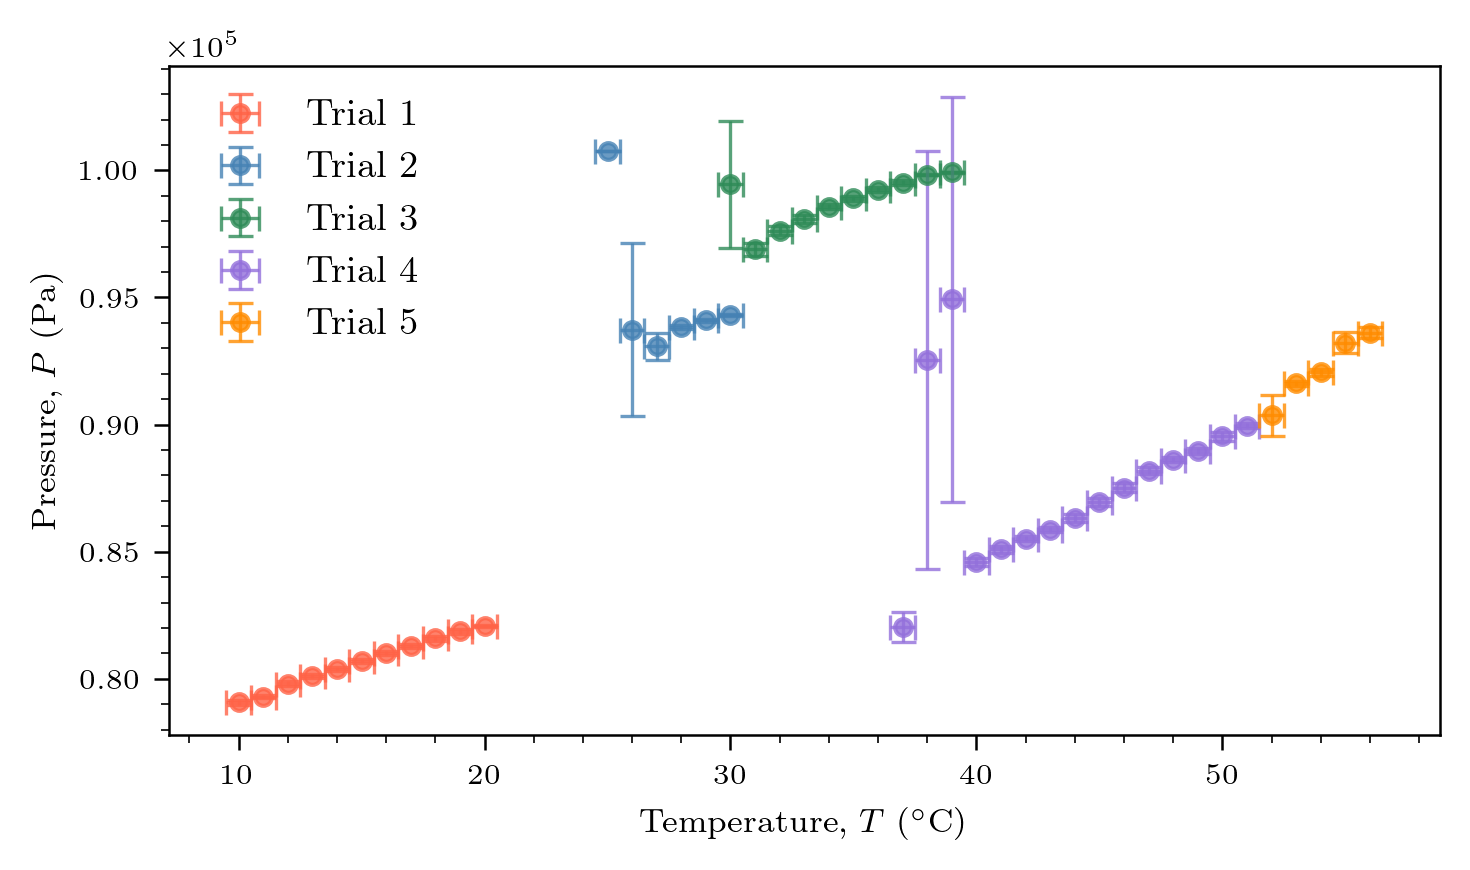

In [ ]:
# =============================================================================
# Pressure vs Temperature
# =============================================================================
# Group all events from every file by 1-degree temperature bin and plot the
# mean pressure with ±1σ error bars.  x-error bars of ±0.5°C reflect the
# bin half-width.
# =============================================================================

def build_pressure_binned(file_list):
    """Bin pressure readings by file and 1-degree temperature bin.

    Returns a DataFrame with columns: file, temp_bin, mean, std.
    """
    dfs = []
    for fname in file_list:
        df = load_data_file(fname)[['temp', 'pressure_pa']].copy()
        df['temp_bin'] = df['temp'].round().astype(int)
        df['file']     = fname
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)
    return (
        df_all.groupby(['file', 'temp_bin'])['pressure_pa']
        .agg(mean='mean', std='std')
        .reset_index()
        .sort_values(['file', 'temp_bin'])
    )

press_binned = build_pressure_binned(all_files)

fig, ax = plt.subplots(figsize=(5, 3))

press_by_file = {fname: grp for fname, grp in press_binned.groupby('file')}
for fname in FILE_LABELS:           # Trial 1 → 5 order
    if fname not in press_by_file:
        continue
    grp = press_by_file[fname]
    c   = FILE_COLORS[fname]
    ax.errorbar(grp['temp_bin'], grp['mean'],
                yerr=grp['std'], xerr=0.5,
                fmt='o', color=c, ms=4, elinewidth=0.8,
                capsize=3, capthick=0.8, alpha=0.8, zorder=3,
                label=FILE_LABELS[fname])

ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.set_xlabel(r'Temperature, $T$ ($^\circ$C)')
ax.set_ylabel(r'Pressure, $P$ (Pa)')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
fig.savefig(DATA_DIR / 'pressure_vs_temperature.png', bbox_inches='tight', dpi=200)
plt.show()


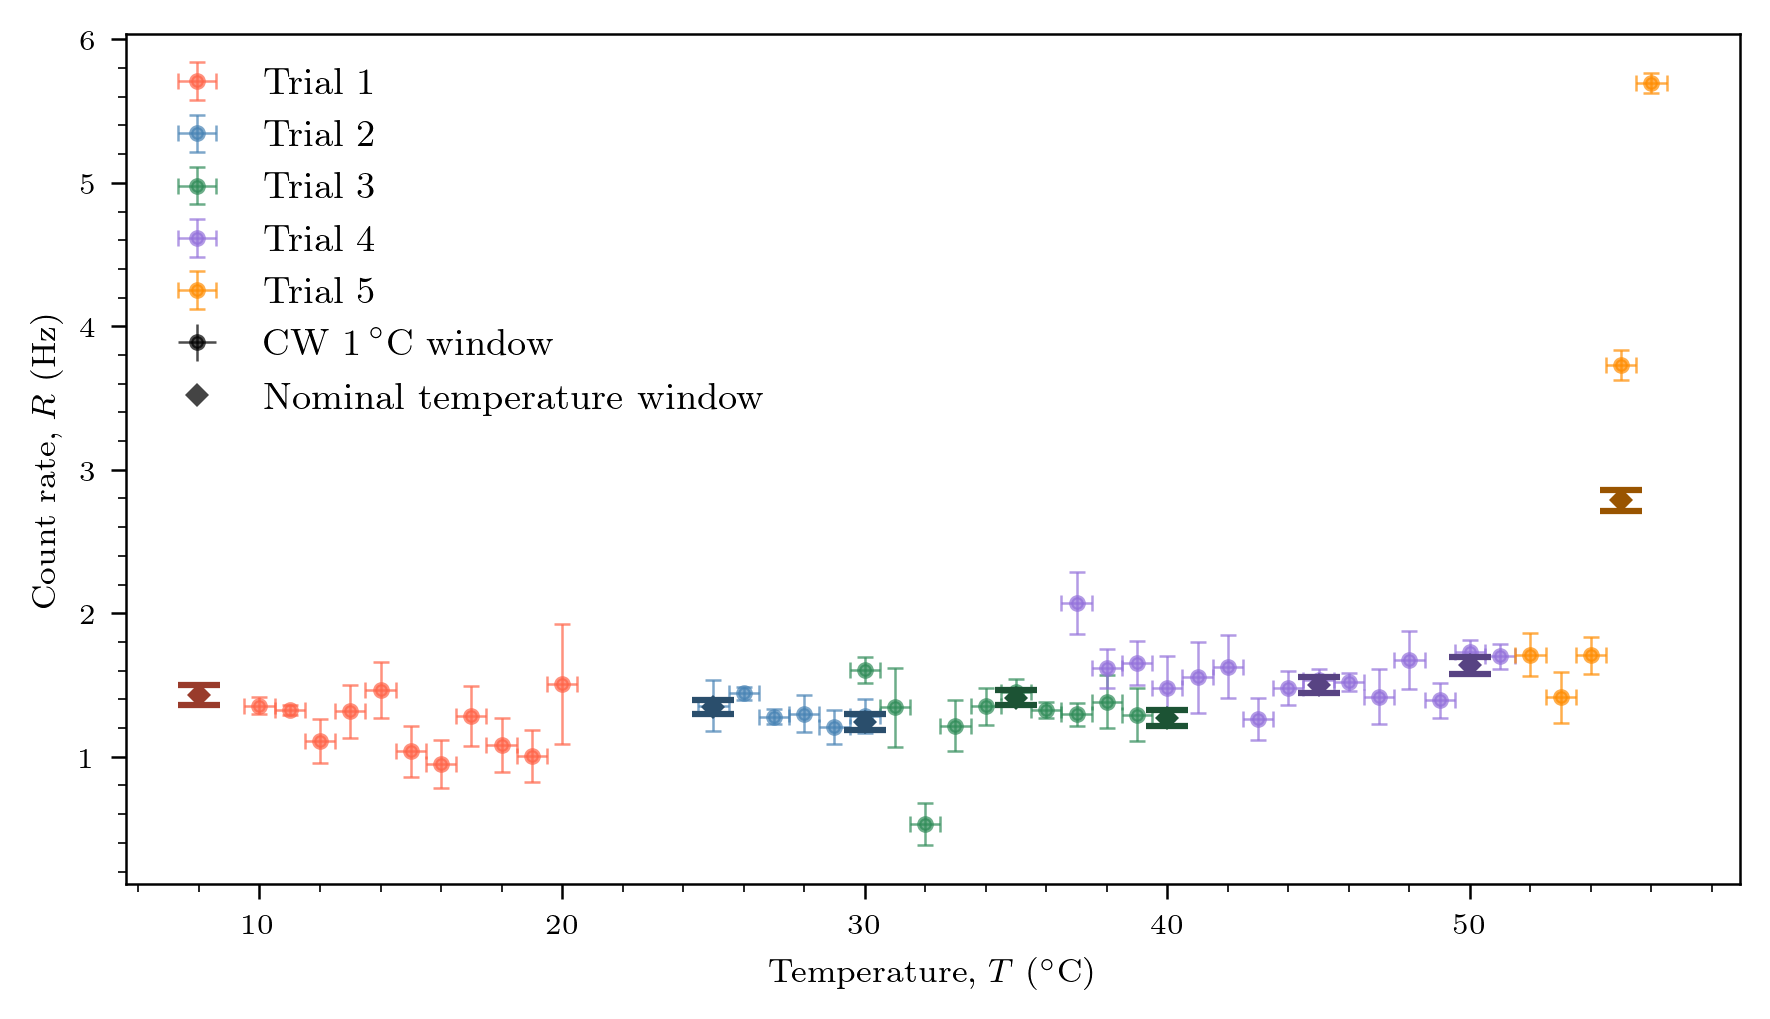

In [ ]:
# =============================================================================
# Count Rate vs Temperature
# =============================================================================
# Per-file 1-degree-binned rates shown as coloured scatter points with
# x (bin half-width) and y (Poisson) error bars.
# Nominal stable-window rates overlaid as darkened diamond markers.
# =============================================================================

from matplotlib.lines import Line2D

def plot_nominal_points(ax, summary, stable_file_map):
    """Overlay nominal stable-window rates as darkened diamond markers."""
    for _, row in summary.iterrows():
        fname = stable_file_map[int(row['temp'])]
        dark  = darken(FILE_COLORS[fname])
        ax.errorbar(row['temp'], row['rate_hz'], yerr=row['rate_err'],
                    fmt='none', ecolor=dark, elinewidth=1.5,
                    capsize=5, capthick=1.5, zorder=4)
        ax.plot(row['temp'], row['rate_hz'], 'D',
                color=dark, ms=4, zorder=5, markeredgewidth=0)

fig, ax = plt.subplots(figsize=(6, 3.5))

fb_by_file = {fname: grp for fname, grp in file_binned.groupby('file')}
for fname in FILE_LABELS:           # Trial 1 → 5 order
    if fname not in fb_by_file:
        continue
    grp = fb_by_file[fname]
    c   = FILE_COLORS[fname]
    ax.errorbar(grp['temp_bin'], grp['rate_hz'],
                yerr=grp['rate_err'], xerr=0.5,
                fmt='o', color=c, ms=3, elinewidth=0.6,
                capsize=2, capthick=0.6, alpha=0.7, zorder=3,
                label=FILE_LABELS[fname])

plot_nominal_points(ax, summary, stable_file_map)

# Proxy for the 1°C-binned scatter points (black circle + error bars)
cw_proxy = ax.errorbar([], [], yerr=[], xerr=[],
                       fmt='o', color='black', ms=3, elinewidth=0.6,
                       capsize=2, capthick=0.6, alpha=0.7)

# Proxy for the nominal stable-window diamond markers
nominal_proxy = Line2D([0], [0], marker='D', color='none',
                       markerfacecolor='#444444', markeredgewidth=0, markersize=4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [cw_proxy, nominal_proxy],
          labels=labels + [r'CW 1$\,^\circ$C window', 'Nominal temperature window'],
          fontsize=9, loc='upper left')

ax.set_xlabel(r'Temperature, $T$ ($^\circ$C)')
ax.set_ylabel(r'Count rate, $R$ (Hz)')
plt.tight_layout()
fig.savefig(DATA_DIR / 'count_rate_vs_temperature.png', bbox_inches='tight', dpi=200)
plt.show()



-- Low-T  (T < 50 C) (40 pts, DOF = 38) --
  ln A     = -11.9992 +/- 0.3693
  E_a      = -0.024 +/- 0.010 eV
  chi2/DOF = 1.839   chi2 = 69.9   p = 0.0012
  ODR stop: ['Sum of squares convergence']

-- High-T (T >= 50 C) (7 pts, DOF = 5) --
  ln A     = 74.4572 +/- 27.3619
  E_a      = 2.4 +/- 0.8 eV
  chi2/DOF = 7.476   chi2 = 37.4   p = 5e-07
  ODR stop: ['Sum of squares convergence']


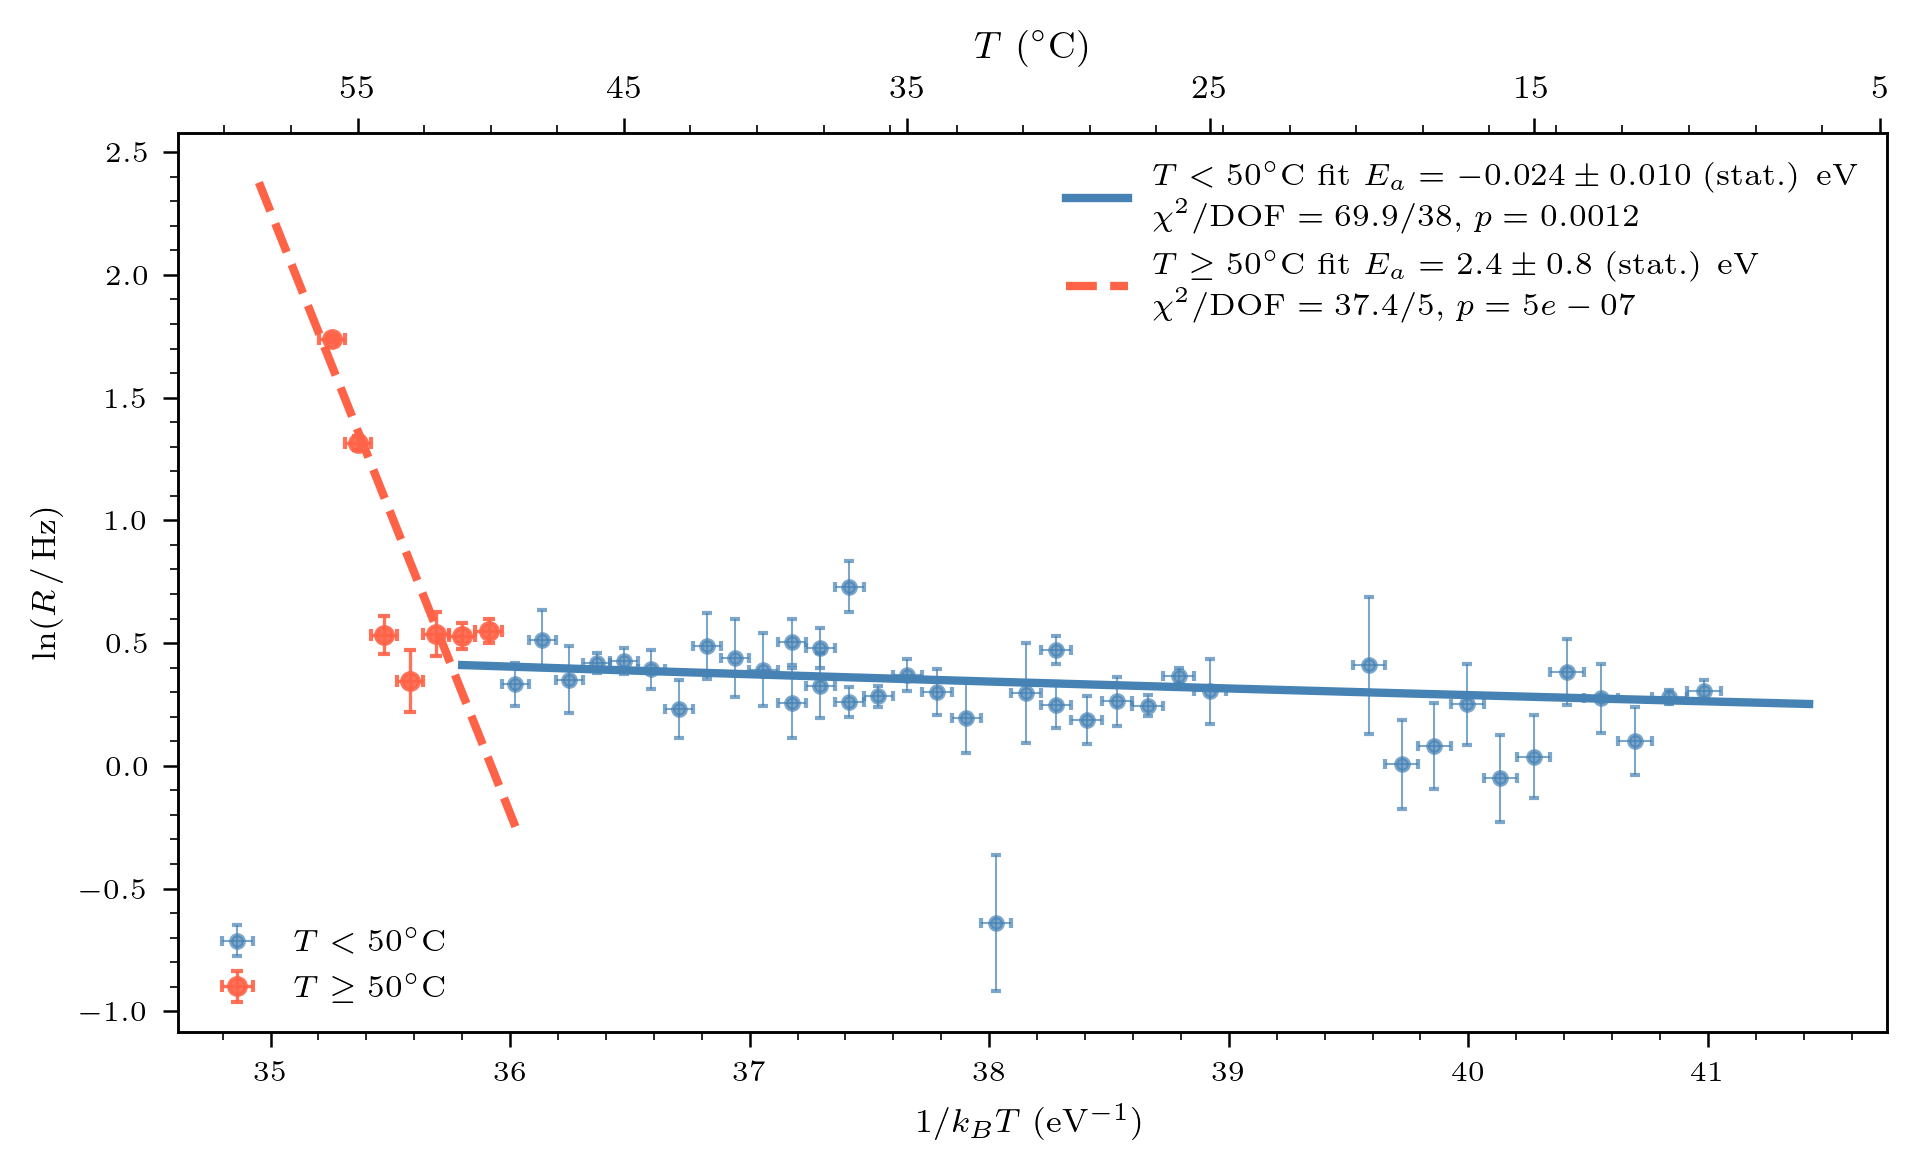

In [ ]:
# =============================================================================
# SRH Fit  (gamma fixed = 2)
# =============================================================================
# SRH generation-recombination model with fixed temperature power-law index:
#
#     R(T) = A * T^2 * exp(-E_a / k_B T)
#
# Fitted in log-space (ln R - 2*ln T = ln A - (E_a/k_B)/T) via ODR.
# Data are split at T_HT_THRESH into two regimes and fitted independently.
# =============================================================================

import scipy.odr as odr_module
from scipy import stats

K_B         = 8.617333e-5  # Boltzmann constant (eV/K)
GAMMA       = 2            # fixed SRH power-law index
T_HT_THRESH = 50 + 273.15  # boundary between low-T and high-T regimes (K)

# =============================================================================
# Helpers
# =============================================================================

def fmt_unc(val, err, max_sig=1):
    """Return (val_str, err_str) with error rounded to max_sig significant figures."""
    if not np.isfinite(err) or err <= 0:
        return f'{val:.3g}', f'{err:.2g}'
    mag      = int(np.floor(np.log10(err)))
    decimals = max(0, -mag + max_sig - 1)
    scale    = 10 ** (-mag + max_sig - 1)
    err_r    = round(err * scale) / scale
    val_r    = round(val * scale) / scale
    return f'{val_r:.{decimals}f}', f'{err_r:.{decimals}f}'

def log_srh_fcn(params, x):
    """ln R = lnA - gamma*ln(x) - (E_a/k_B)*x,  where x = 1/T."""
    lnA, EaKB = params
    return lnA - GAMMA * np.log(x) - EaKB * x

def run_odr(T_arr, R_arr, T_err, R_err, label):
    """Fit the fixed-gamma SRH model in log-space via ODR.

    y = ln(R),  x = 1/T,  y_err = R_err/R,  x_err = T_err/T^2.
    Returns (odr_output, chi2, dof, p_value, Ea_eV, Ea_err_eV).
    """
    x     = 1.0 / T_arr
    y     = np.log(R_arr)
    x_err = T_err / T_arr**2
    y_err = R_err / R_arr

    x_mid = x.mean()
    lnA0  = y.mean() + GAMMA * np.log(x_mid) + (0.28 / K_B) * x_mid

    out = odr_module.ODR(
        odr_module.RealData(x, y, sx=x_err, sy=y_err),
        odr_module.Model(log_srh_fcn),
        beta0=[lnA0, 0.28 / K_B],
        maxit=2000,
    ).run()

    dof    = len(T_arr) - 2
    chi2   = out.res_var * dof
    p      = stats.chi2.sf(chi2, df=dof) if dof > 0 else float('nan')
    Ea     = out.beta[1] * K_B
    Ea_err = out.sd_beta[1] * K_B

    v, e = fmt_unc(Ea, Ea_err)
    print(f'\n-- {label} ({len(T_arr)} pts, DOF = {dof}) --')
    print(f'  ln A     = {out.beta[0]:.4f} +/- {out.sd_beta[0]:.4f}')
    print(f'  E_a      = {v} +/- {e} eV')
    if dof > 0:
        print(f'  chi2/DOF = {out.res_var:.3f}   chi2 = {chi2:.1f}   p = {p:.2g}')
    else:
        print('  DOF = 0 -- exactly determined, no chi2')
    print(f'  ODR stop: {out.stopreason}')
    return out, chi2, dof, p, Ea, Ea_err

def fit_label(name, Ea, Ea_err, res_var, dof, p):
    v, e   = fmt_unc(Ea, Ea_err, max_sig=1)
    first  = f'{name}  $E_a = {v} \\pm {e}$ (stat.) eV'
    if dof > 0:
        chi2   = res_var * dof
        second = f'$\\chi^2/\\mathrm{{DOF}} = {chi2:.1f} / {dof}$,  $p = {p:.2g}$'
    else:
        second = 'DOF=0'
    return first + '\n' + second

# =============================================================================
# Prepare datasets
# =============================================================================

T_bin     = (file_binned['temp_bin'].values + 273.15).astype(float)
T_bin_err = np.full(len(T_bin), 0.5)
R_bin     = file_binned['rate_hz'].values.astype(float)
R_bin_err = file_binned['rate_err'].values.astype(float)

# Split at threshold into two regimes
mask_hT = T_bin >= T_HT_THRESH
mask_lT = ~mask_hT

T_hT, T_hT_err = T_bin[mask_hT], T_bin_err[mask_hT]
R_hT, R_hT_err = R_bin[mask_hT], R_bin_err[mask_hT]

T_lT, T_lT_err = T_bin[mask_lT], T_bin_err[mask_lT]
R_lT, R_lT_err = R_bin[mask_lT], R_bin_err[mask_lT]

# =============================================================================
# Run ODR fits
# =============================================================================

out_lT, chi2_lT, dof_lT, p_lT, Ea_lT, Ea_lT_err = run_odr(
    T_lT, R_lT, T_lT_err, R_lT_err, f'Low-T  (T < {int(T_HT_THRESH - 273.15)} C)')
out_hT, chi2_hT, dof_hT, p_hT, Ea_hT, Ea_hT_err = run_odr(
    T_hT, R_hT, T_hT_err, R_hT_err, f'High-T (T >= {int(T_HT_THRESH - 273.15)} C)')

# =============================================================================
# Arrhenius-style plot  (y-axis: ln R  vs  1/(k_B T))
# =============================================================================

T_thresh_str_lo = f'$T < {int(T_HT_THRESH - 273.15)}^\\circ$C'
T_thresh_str_hi = f'$T \\geq {int(T_HT_THRESH - 273.15)}^\\circ$C'

y_lT     = np.log(R_lT)
y_lT_err = R_lT_err / R_lT
y_hT     = np.log(R_hT)
y_hT_err = R_hT_err / R_hT

fig, ax = plt.subplots(figsize=(6.5, 4))

# --- Data points ---

h_lT_pts = ax.errorbar(
    1.0 / (K_B * T_lT), y_lT,
    yerr=y_lT_err, xerr=T_lT_err / (K_B * T_lT**2),
    fmt='o', color='steelblue', ms=3, elinewidth=0.5, capsize=1.2,
    alpha=0.7, zorder=2, label=T_thresh_str_lo)

h_hT_pts = ax.errorbar(
    1.0 / (K_B * T_hT), y_hT,
    yerr=y_hT_err, xerr=T_hT_err / (K_B * T_hT**2),
    fmt='o', color='tomato', ms=4, elinewidth=0.8, capsize=1.5,
    alpha=0.9, zorder=4, label=T_thresh_str_hi)

# --- Fit curves ---

T_fine_lT = np.linspace(T_lT.min() - 3, T_HT_THRESH + 1, 300)
x_fine_lT = 1.0 / (K_B * T_fine_lT)
T_fine_hT = np.linspace(T_HT_THRESH - 1, T_hT.max() + 3, 300)
x_fine_hT = 1.0 / (K_B * T_fine_hT)

h_lT_fit, = ax.plot(
    x_fine_lT,
    log_srh_fcn(out_lT.beta, 1.0 / T_fine_lT),
    '-', color='steelblue', lw=2.0, zorder=6,
    label=fit_label(T_thresh_str_lo + ' fit', Ea_lT, Ea_lT_err,
                    out_lT.res_var, dof_lT, p_lT))

h_hT_fit, = ax.plot(
    x_fine_hT,
    log_srh_fcn(out_hT.beta, 1.0 / T_fine_hT),
    '--', color='tomato', lw=2.0, zorder=7,
    label=fit_label(T_thresh_str_hi + ' fit', Ea_hT, Ea_hT_err,
                    out_hT.res_var, dof_hT, p_hT))

# --- Secondary x-axis in °C ---
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
T_ticks_K = np.array([5, 15, 25, 35, 45, 55]) + 273.15
ax2.set_xticks(1.0 / (K_B * T_ticks_K))
ax2.set_xticklabels([str(int(T - 273.15)) for T in T_ticks_K], fontsize=8)
ax2.set_xlabel(r'$T$ ($^\circ$C)', fontsize=9)

# --- Split legend: fits upper-right, data points lower-left ---
leg_fits = ax.legend(handles=[h_lT_fit, h_hT_fit], loc='upper right', fontsize=7.5)
ax.add_artist(leg_fits)
ax.legend(handles=[h_lT_pts, h_hT_pts], loc='lower left', fontsize=7.5)

ax.set_xlabel(r'$1/k_BT\ (\mathrm{eV}^{-1})$')
ax.set_ylabel(r'$\ln(R\,/\,\mathrm{Hz})$')
plt.tight_layout()
fig.savefig(DATA_DIR / 'arrhenius_fit.png', bbox_inches='tight', dpi=200)
plt.show()

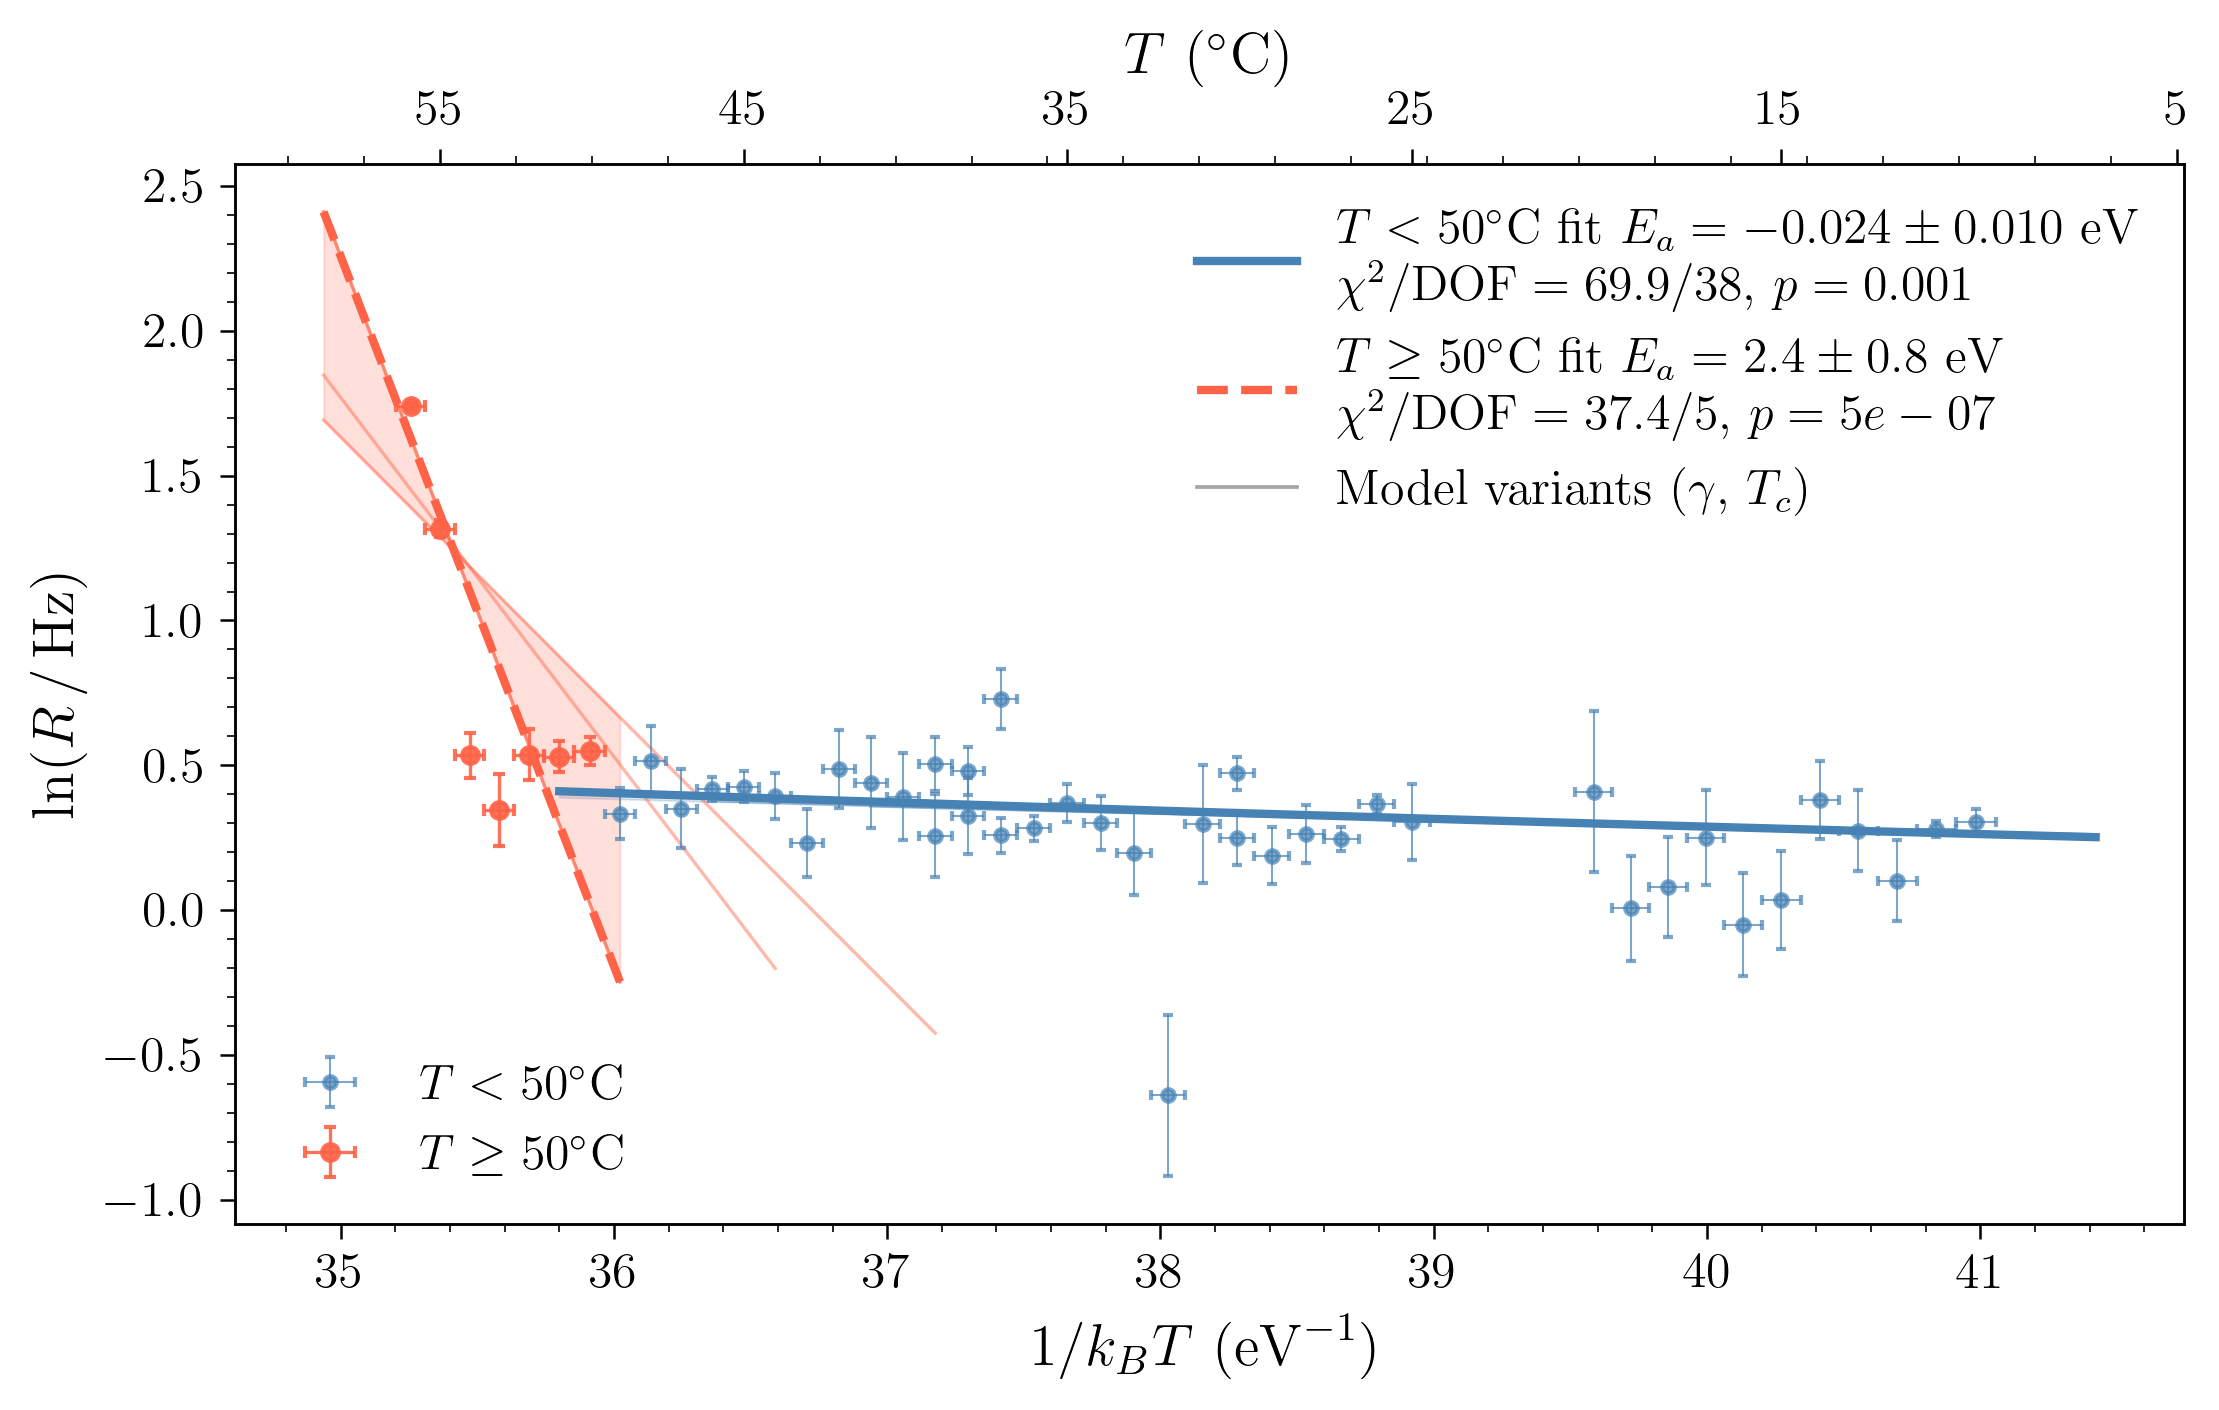

In [ ]:
# =============================================================================
# Arrhenius plot — systematics envelope
# Overlays fit curves for all gamma and T_c variants to show systematic spread
# =============================================================================

def _full_srh_fit(T_arr, R_arr, T_err, R_err, gamma, t_thresh_k):
    """Re-run SRH ODR for given gamma and cutoff; return {regime: (beta, gamma)}."""
    def _model(params, x):
        lnA, EaKB = params
        return lnA - gamma * np.log(x) - EaKB * x
    out_dict = {}
    for regime, mask in [('lT', T_arr < t_thresh_k), ('hT', T_arr >= t_thresh_k)]:
        T, R, Te, Re = T_arr[mask], R_arr[mask], T_err[mask], R_err[mask]
        if len(T) < 3:
            out_dict[regime] = None
            continue
        x, y   = 1.0 / T, np.log(R)
        x_mid  = x.mean()
        lnA0   = y.mean() + gamma * np.log(x_mid) + (0.28 / K_B) * x_mid
        try:
            fit = odr_module.ODR(
                odr_module.RealData(x, y, sx=Te / T**2, sy=Re / R),
                odr_module.Model(_model),
                beta0=[lnA0, 0.28 / K_B], maxit=2000,
            ).run()
            out_dict[regime] = (fit.beta, gamma)
        except Exception:
            out_dict[regime] = None
    return out_dict

def _lnR_curve(beta, gamma, T_fine):
    """Evaluate ln(R) = lnA + gamma*ln(T) - EaKB/T."""
    lnA, EaKB = beta
    return lnA + gamma * np.log(T_fine) - EaKB / T_fine

def _fit_label_sf1(name, Ea, Ea_err, res_var, dof, p):
    v, e = fmt_unc(Ea, Ea_err, max_sig=1)
    first  = f'{name}  $E_a = {v} \\pm {e}$ eV'
    if dof > 0:
        chi2   = res_var * dof
        second = f'$\\chi^2/\\mathrm{{DOF}} = {chi2:.1f}/{dof}$,  $p = {p:.1g}$'
    else:
        second = 'DOF=0'
    return first + '\n' + second

# --- Compute all variant fits ---
GAMMA_VARS  = [1, 2, 3]
CUTOFF_VARS = [40, 45, 50]  # °C  (T_c=55 dropped: <3 points above 55°C)

gamma_fits  = {g:  _full_srh_fit(T_bin, R_bin, T_bin_err, R_bin_err, g,    T_HT_THRESH)
               for g  in GAMMA_VARS}
cutoff_fits = {tc: _full_srh_fit(T_bin, R_bin, T_bin_err, R_bin_err, GAMMA, tc + 273.15)
               for tc in CUTOFF_VARS}

T_min_data = T_bin.min()
T_max_data = T_bin.max()

# --- T grids for each regime ---
T_fine_lT_s = np.linspace(T_min_data - 3, T_HT_THRESH + 1, 300)
T_fine_hT_s = np.linspace(T_HT_THRESH - 1, T_max_data + 3, 300)
x_fine_lT_s = 1.0 / (K_B * T_fine_lT_s)
x_fine_hT_s = 1.0 / (K_B * T_fine_hT_s)

# --- Collect all variant curves for envelope ---
lT_ys, hT_ys = [], []
for g in GAMMA_VARS:
    if gamma_fits[g]['lT'] is not None:
        b, gam = gamma_fits[g]['lT']
        lT_ys.append(_lnR_curve(b, gam, T_fine_lT_s))
    if gamma_fits[g]['hT'] is not None:
        b, gam = gamma_fits[g]['hT']
        hT_ys.append(_lnR_curve(b, gam, T_fine_hT_s))
for tc in CUTOFF_VARS:
    if cutoff_fits[tc]['lT'] is not None:
        b, gam = cutoff_fits[tc]['lT']
        lT_ys.append(_lnR_curve(b, gam, T_fine_lT_s))
    if cutoff_fits[tc]['hT'] is not None:
        b, gam = cutoff_fits[tc]['hT']
        hT_ys.append(_lnR_curve(b, gam, T_fine_hT_s))

lT_stack = np.array(lT_ys)
hT_stack = np.array(hT_ys)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.5, 4.8))

# Filled envelope
ax.fill_between(x_fine_lT_s, lT_stack.min(axis=0), lT_stack.max(axis=0),
                color='steelblue', alpha=0.20, zorder=3)
ax.fill_between(x_fine_hT_s, hT_stack.min(axis=0), hT_stack.max(axis=0),
                color='tomato',   alpha=0.20, zorder=3)

# Individual thin variant curves within the band
for g in [1, 3]:
    fit = gamma_fits[g]
    if fit['lT'] is not None:
        b, gam = fit['lT']
        ax.plot(x_fine_lT_s, _lnR_curve(b, gam, T_fine_lT_s),
                '-', color='steelblue', lw=0.8, alpha=0.45, zorder=4)
    if fit['hT'] is not None:
        b, gam = fit['hT']
        ax.plot(x_fine_hT_s, _lnR_curve(b, gam, T_fine_hT_s),
                '-', color='tomato', lw=0.8, alpha=0.45, zorder=4)

for tc in [40, 45]:
    thresh_k = tc + 273.15
    fit = cutoff_fits[tc]
    if fit['lT'] is not None:
        b, gam = fit['lT']
        T_lT_cut = T_bin[T_bin < thresh_k]
        T_fine_cut = np.linspace(T_lT_cut.min() - 3, thresh_k + 1, 300)
        ax.plot(1.0 / (K_B * T_fine_cut), _lnR_curve(b, gam, T_fine_cut),
                '-', color='steelblue', lw=0.8, alpha=0.45, zorder=4)
    if fit['hT'] is not None:
        b, gam = fit['hT']
        T_hT_cut = T_bin[T_bin >= thresh_k]
        T_fine_cut = np.linspace(thresh_k - 1, T_hT_cut.max() + 3, 300)
        ax.plot(1.0 / (K_B * T_fine_cut), _lnR_curve(b, gam, T_fine_cut),
                '-', color='tomato', lw=0.8, alpha=0.45, zorder=4)

# Data points
h_lT_pts = ax.errorbar(
    1.0 / (K_B * T_lT), np.log(R_lT),
    yerr=R_lT_err / R_lT, xerr=T_lT_err / (K_B * T_lT**2),
    fmt='o', color='steelblue', ms=3, elinewidth=0.5, capsize=1.2,
    alpha=0.7, zorder=5, label=T_thresh_str_lo)

h_hT_pts = ax.errorbar(
    1.0 / (K_B * T_hT), np.log(R_hT),
    yerr=R_hT_err / R_hT, xerr=T_hT_err / (K_B * T_hT**2),
    fmt='o', color='tomato', ms=4, elinewidth=0.8, capsize=1.5,
    alpha=0.9, zorder=6, label=T_thresh_str_hi)

# Nominal fit curves (bold)
h_lT_fit, = ax.plot(x_fine_lT_s, log_srh_fcn(out_lT.beta, 1.0 / T_fine_lT_s),
                    '-', color='steelblue', lw=2.0, zorder=7,
                    label=_fit_label_sf1(T_thresh_str_lo + ' fit', Ea_lT, Ea_lT_err,
                                         out_lT.res_var, dof_lT, p_lT))
h_hT_fit, = ax.plot(x_fine_hT_s, log_srh_fcn(out_hT.beta, 1.0 / T_fine_hT_s),
                    '--', color='tomato', lw=2.0, zorder=7,
                    label=_fit_label_sf1(T_thresh_str_hi + ' fit', Ea_hT, Ea_hT_err,
                                         out_hT.res_var, dof_hT, p_hT))

# --- Secondary x-axis in °C ---
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
T_ticks_K = np.array([5, 15, 25, 35, 45, 55]) + 273.15
ax2.set_xticks(1.0 / (K_B * T_ticks_K))
ax2.set_xticklabels([str(int(T - 273.15)) for T in T_ticks_K], fontsize=12)
ax2.set_xlabel(r'$T$ ($^\circ$C)', fontsize=14)

# --- Legend ---
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
variant_proxy = Line2D([0], [0], ls='-', color='gray', lw=0.9, alpha=0.7,
                       label=r'Model variants ($\gamma$, $T_c$)')
leg_fits = ax.legend(handles=[h_lT_fit, h_hT_fit, variant_proxy],
                     loc='upper right', fontsize=12)
ax.add_artist(leg_fits)
ax.legend(handles=[h_lT_pts, h_hT_pts], loc='lower left', fontsize=12)

ax.set_xlabel(r'$1/k_BT\ (\mathrm{eV}^{-1})$', fontsize=14)
ax.set_ylabel(r'$\ln(R\,/\,\mathrm{Hz})$', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
fig.savefig(DATA_DIR / 'arrhenius_systematics.png', bbox_inches='tight', dpi=200)
plt.show()

T > 50 C : 8,717 events
T < 50 C : 7,792 events


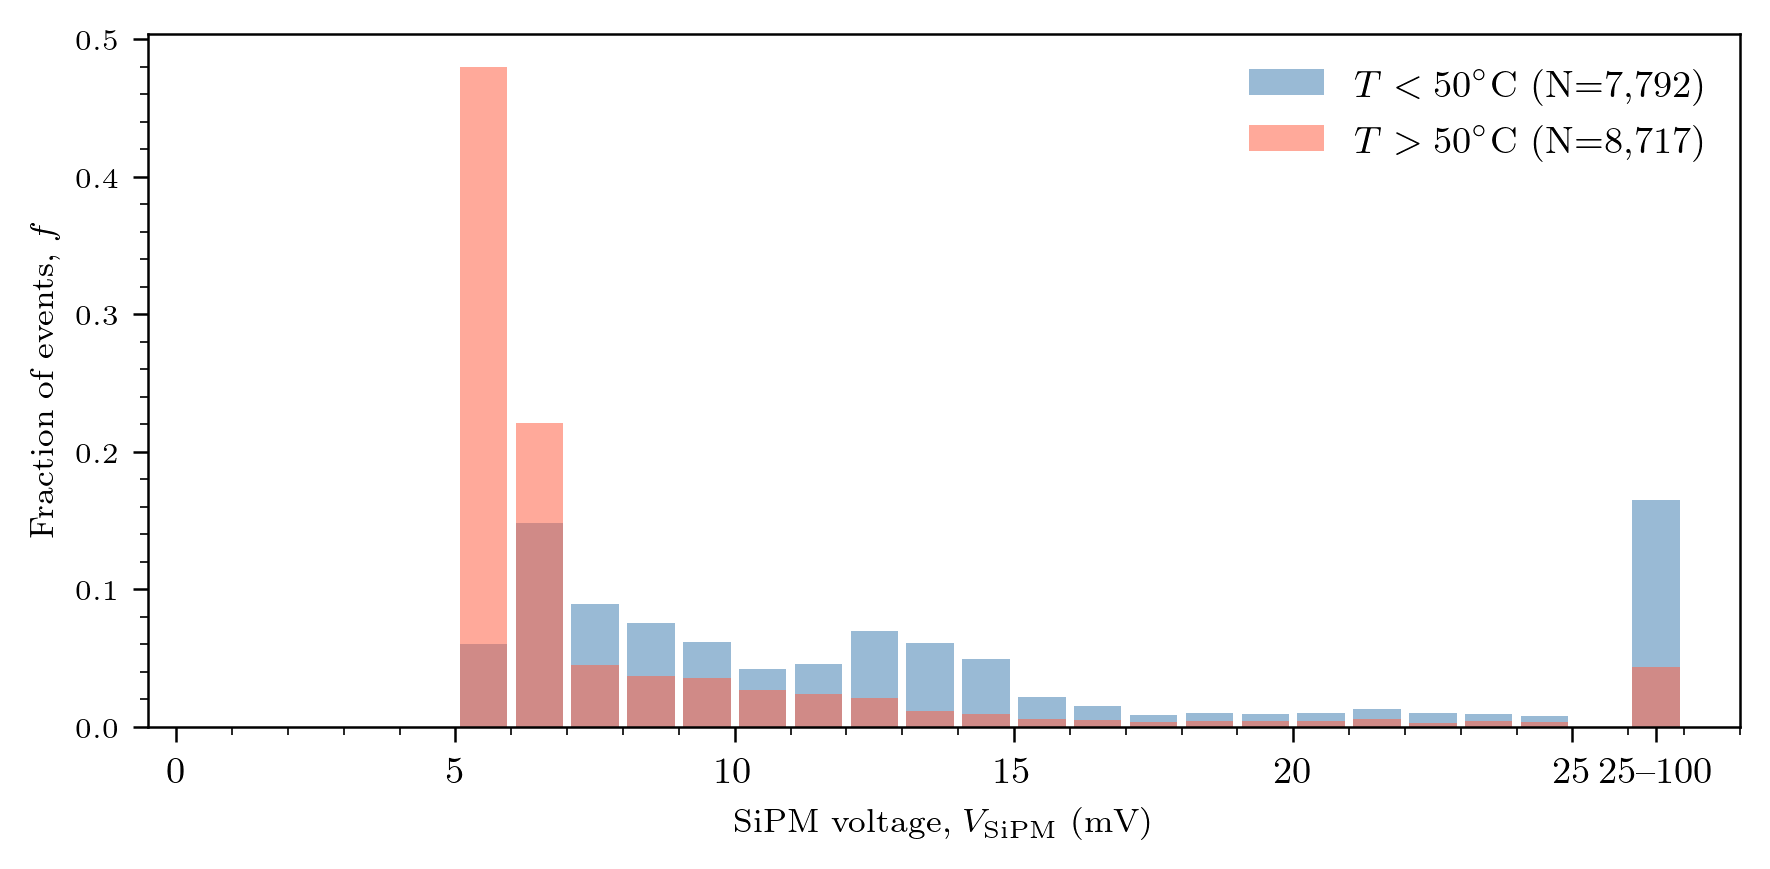

In [ ]:
# =============================================================================
# SiPM Pulse-Height Distribution by Temperature
# =============================================================================
# Compares the SiPM pulse-height spectrum (a proxy for deposited energy)
# above and below T_c to test for temperature-dependent spectral
# shifts.
#
# Histogram layout:
#   - 1 mV bins from 0 to MV_FINE mV  (fine region)
#   - One aggregated bar for MV_FINE to MV_MAX mV
# =============================================================================

T_CUT   = int(T_HT_THRESH - 273.15)  # match SRH regime cutoff
MV_FINE = 25   # upper edge of the 1-mV-binned region (mV)
MV_MAX  = 100  # upper edge of the aggregated tail bin (mV)
BAR_W   = 0.85

def load_sipm_data(file_list):
    """Load SiPM pulse heights and temperatures from all data files.

    Returns a DataFrame with columns: sipm_mv, temp.
    """
    return pd.concat(
        [load_data_file(fname)[['sipm_mv', 'temp']] for fname in file_list],
        ignore_index=True,
    )

def plot_sipm_histogram(ax, above_mv, below_mv, T_cut,
                        mv_fine=MV_FINE, mv_max=MV_MAX):
    """Draw the dual pulse-height histogram on ax.

    Parameters
    ----------
    ax       : matplotlib Axes
    above_mv : SiPM values (mV) for events with T > T_cut
    below_mv : SiPM values (mV) for events with T < T_cut
    T_cut    : temperature threshold (°C) used for the legend labels
    mv_fine  : upper edge of the fine (1-mV) binning region
    mv_max   : upper edge of the aggregated tail bin
    """
    N_above, N_below = len(above_mv), len(below_mv)

    bin_edges   = np.arange(0, mv_fine + 1, 1)
    bin_centers = bin_edges[:-1] + 0.5

    counts_below, _ = np.histogram(below_mv, bins=bin_edges)
    counts_above, _ = np.histogram(above_mv, bins=bin_edges)

    agg_below = np.sum((below_mv >= mv_fine) & (below_mv <= mv_max))
    agg_above = np.sum((above_mv >= mv_fine) & (above_mv <= mv_max))
    agg_x     = mv_fine + 1.5  # bar centre just past the fine-bin region

    # Fine-bin bars (normalised to fraction of events per group)
    ax.bar(bin_centers, counts_below / N_below, width=BAR_W,
           color='steelblue', alpha=0.55,
           label=f'$T < {T_cut}^\\circ$C  (N={N_below:,})')
    ax.bar(bin_centers, counts_above / N_above, width=BAR_W,
           color='tomato', alpha=0.55,
           label=f'$T > {T_cut}^\\circ$C  (N={N_above:,})')

    # Aggregated tail bin
    ax.bar(agg_x, agg_below / N_below, width=BAR_W, color='steelblue', alpha=0.55)
    ax.bar(agg_x, agg_above / N_above, width=BAR_W, color='tomato',    alpha=0.55)

    # x-ticks: 5 mV steps in the fine region + one label for the tail bin
    fine_ticks = list(range(0, mv_fine + 1, 5))
    ax.set_xticks(fine_ticks + [agg_x])
    ax.set_xticklabels([str(t) for t in fine_ticks] + [f'{mv_fine}--{mv_max}'],
                       fontsize=9)
    ax.set_xlim(-0.5, agg_x + 1.5)
    ax.set_xlabel(r'SiPM voltage, $V_{\mathrm{SiPM}}$ (mV)')
    ax.set_ylabel(r'Fraction of events, $f$')

# --- Execute -----------------------------------------------------------------

df_sipm = load_sipm_data(all_files)
above   = df_sipm[df_sipm['temp'] >  T_CUT]['sipm_mv'].values
below   = df_sipm[df_sipm['temp'] <  T_CUT]['sipm_mv'].values

print(f'T > {T_CUT} C : {len(above):,} events')
print(f'T < {T_CUT} C : {len(below):,} events')

fig, ax = plt.subplots(figsize=(6, 3))
plot_sipm_histogram(ax, above, below, T_CUT)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(DATA_DIR / 'sipm_energy.png', bbox_inches='tight', dpi=200)
plt.show()


In [ ]:
# =============================================================================
# Systematic Error Analysis and Apparatus Consistency Check
# =============================================================================
# Systematically varies gamma (1, 2, 3) and the low/high-T cutoff (40-55 C)
# to estimate systematic uncertainties on E_a for both regimes.
# Also estimates inter-trial apparatus scatter and compares it to the
# rate excess at T >= 50 C to test whether the high-T points are real.
# =============================================================================

from itertools import combinations as _combinations

# --- Helper: re-run SRH ODR for arbitrary gamma and cutoff ---

def run_srh_fit(T_arr, R_arr, T_err, R_err, gamma, t_thresh_k):
    """Return {'lT': (Ea, Ea_err), 'hT': (Ea, Ea_err)} for given gamma and cutoff."""
    def model(params, x):
        lnA, EaKB = params
        return lnA - gamma * np.log(x) - EaKB * x

    result = {}
    for regime, mask in [('lT', T_arr < t_thresh_k), ('hT', T_arr >= t_thresh_k)]:
        T, R, Te, Re = T_arr[mask], R_arr[mask], T_err[mask], R_err[mask]
        if len(T) < 3:
            result[regime] = (np.nan, np.nan)
            continue
        x, y = 1.0 / T, np.log(R)
        x_mid = x.mean()
        lnA0  = y.mean() + gamma * np.log(x_mid) + (0.28 / K_B) * x_mid
        try:
            out = odr_module.ODR(
                odr_module.RealData(x, y, sx=Te / T**2, sy=Re / R),
                odr_module.Model(model),
                beta0=[lnA0, 0.28 / K_B], maxit=2000,
            ).run()
            Ea = out.beta[1] * K_B
            result[regime] = (Ea, out.sd_beta[1] * K_B) if np.isfinite(Ea) else (np.nan, np.nan)
        except Exception:
            result[regime] = (np.nan, np.nan)
    return result

# =============================================================================
# 1. Systematic from gamma  (vary gamma = 1, 2, 3)
# =============================================================================

print('=== 1. Gamma systematic ===')
gamma_Ea = {}
for g in [1, 2, 3]:
    gamma_Ea[g] = run_srh_fit(T_bin, R_bin, T_bin_err, R_bin_err, g, T_HT_THRESH)
    vl, el = fmt_unc(*gamma_Ea[g]['lT'])
    vh, eh = fmt_unc(*gamma_Ea[g]['hT'])
    print(f'  gamma={g}:  Ea(low-T) = {vl} +/- {el} eV   Ea(high-T) = {vh} +/- {eh} eV')

sys_gamma_lT = abs(gamma_Ea[3]['lT'][0] - gamma_Ea[1]['lT'][0]) / 2
sys_gamma_hT = abs(gamma_Ea[3]['hT'][0] - gamma_Ea[1]['hT'][0]) / 2
vgl, _ = fmt_unc(sys_gamma_lT, sys_gamma_lT)
vgh, _ = fmt_unc(sys_gamma_hT, sys_gamma_hT)
print(f'  => sigma_sys(gamma)  low-T = {vgl} eV   high-T = {vgh} eV')

# =============================================================================
# 2. Systematic from cutoff temperature  (vary cutoff 40 -> 55 C)
# =============================================================================

print('\n=== 2. Cutoff temperature systematic ===')
T_CUTS = [40, 45, 50, 55]
cutoff_Ea = {}
for t_cut in T_CUTS:
    cutoff_Ea[t_cut] = run_srh_fit(T_bin, R_bin, T_bin_err, R_bin_err, GAMMA, t_cut + 273.15)
    lT_ok = np.isfinite(cutoff_Ea[t_cut]['lT'][0])
    hT_ok = np.isfinite(cutoff_Ea[t_cut]['hT'][0])
    if lT_ok and hT_ok:
        vl, _ = fmt_unc(cutoff_Ea[t_cut]['lT'][0], cutoff_Ea[t_cut]['lT'][1])
        vh, _ = fmt_unc(cutoff_Ea[t_cut]['hT'][0], cutoff_Ea[t_cut]['hT'][1])
        print(f'  T_cut={t_cut} C:  Ea(low-T) = {vl} eV   Ea(high-T) = {vh} eV')
    else:
        print(f'  T_cut={t_cut} C:  insufficient data for one or both regimes')

valid_lT_cuts = [cutoff_Ea[t]['lT'][0] for t in T_CUTS if np.isfinite(cutoff_Ea[t]['lT'][0])]
valid_hT_cuts = [cutoff_Ea[t]['hT'][0] for t in T_CUTS if np.isfinite(cutoff_Ea[t]['hT'][0])]
sys_cutoff_lT = (max(valid_lT_cuts) - min(valid_lT_cuts)) / 2 if len(valid_lT_cuts) >= 2 else np.nan
sys_cutoff_hT = (max(valid_hT_cuts) - min(valid_hT_cuts)) / 2 if len(valid_hT_cuts) >= 2 else np.nan
vcl, _ = fmt_unc(sys_cutoff_lT, sys_cutoff_lT)
vch, _ = fmt_unc(sys_cutoff_hT, sys_cutoff_hT)
print(f'  => sigma_sys(cutoff) low-T = {vcl} eV   high-T = {vch} eV')

# =============================================================================
# 3. Apparatus systematic — inter-trial rate scatter at shared temperatures
# =============================================================================

print('\n=== 3. Apparatus systematic ===')

# For each temperature bin present in >= 2 files, collect all pairwise |delta R|
pivot = file_binned.pivot_table(index='temp_bin', columns='file',
                                values='rate_hz', aggfunc='mean')
inter_trial_diffs = []
n_shared = 0
for _, row in pivot.iterrows():
    vals = row.dropna()
    if len(vals) >= 2:
        n_shared += 1
        for (_, r1), (_, r2) in _combinations(vals.items(), 2):
            inter_trial_diffs.append(abs(r1 - r2))

apparatus_sys = np.mean(inter_trial_diffs) if inter_trial_diffs else np.nan
apparatus_std = np.std(inter_trial_diffs)  if inter_trial_diffs else np.nan

# Rate excess: actual high-T rates vs prediction extrapolated from the low-T fit
# log_srh_fcn(out_lT.beta, 1/T) gives ln(R) under the low-T model
R_hT_pred       = np.exp(log_srh_fcn(out_lT.beta, 1.0 / T_hT))
rate_excess      = np.mean(R_hT - R_hT_pred)
rate_excess_std  = np.std(R_hT  - R_hT_pred)

print(f'  Shared temperature bins (>= 2 trials): {n_shared}')
print(f'  Total pairwise rate comparisons:       {len(inter_trial_diffs)}')
print(f'  Mean inter-trial |delta R| at same T:  {apparatus_sys:.4f} +/- {apparatus_std:.4f} Hz')
print(f'  Mean rate excess at T >= 50 C          {rate_excess:.4f} +/- {rate_excess_std:.4f} Hz')
print(f'  Excess / apparatus sys:                {rate_excess / apparatus_sys:.1f}x')

if rate_excess > 2 * apparatus_sys:
    conclusion = (f'REAL SIGNAL: excess ({rate_excess:.3f} Hz) is '
                  f'{rate_excess/apparatus_sys:.1f}x the apparatus systematic '
                  f'({apparatus_sys:.3f} Hz) — cannot be explained by trial-to-trial drift.')
else:
    conclusion = (f'AMBIGUOUS: excess ({rate_excess:.3f} Hz) is only '
                  f'{rate_excess/apparatus_sys:.1f}x the apparatus systematic '
                  f'({apparatus_sys:.3f} Hz) — consistent with apparatus drift.')
print(f'\n  => {conclusion}')

# =============================================================================
# Summary table
# =============================================================================

tot_sys_lT = np.sqrt(sys_gamma_lT**2 + sys_cutoff_lT**2)
tot_sys_hT = np.sqrt(sys_gamma_hT**2 + sys_cutoff_hT**2)
tot_lT     = np.sqrt(Ea_lT_err**2 + tot_sys_lT**2)
tot_hT     = np.sqrt(Ea_hT_err**2 + tot_sys_hT**2)

def _r(v):
    s, _ = fmt_unc(v, v)
    return f'+/- {s}'

SEP = '=' * 68
sep = '-' * 68
print('\n' + SEP)
print(f'  {"SYSTEMATIC ERROR SUMMARY":^64}')
print(SEP)
print(f'  {"Source":<34}  {"Low-T (<50 C)":>14}  {"High-T (>=50 C)":>14}')
print(sep)

vls, els = fmt_unc(Ea_lT, Ea_lT_err)
vhs, ehs = fmt_unc(Ea_hT, Ea_hT_err)
print(f'  {"E_a (eV)":<34}  {vls+" +/- "+els:>14}  {vhs+" +/- "+ehs:>14}')
print(f'  {"sigma_stat (eV)":<34}  {_r(Ea_lT_err):>14}  {_r(Ea_hT_err):>14}')
print(f'  {"sigma_sys gamma (eV)":<34}  {_r(sys_gamma_lT):>14}  {_r(sys_gamma_hT):>14}')
print(f'  {"sigma_sys cutoff T (eV)":<34}  {_r(sys_cutoff_lT):>14}  {_r(sys_cutoff_hT):>14}')
print(sep)
print(f'  {"sigma_sys total in quadrature (eV)":<34}  {_r(tot_sys_lT):>14}  {_r(tot_sys_hT):>14}')
print(f'  {"sigma_total (stat+sys) (eV)":<34}  {_r(tot_lT):>14}  {_r(tot_hT):>14}')
print(SEP)
print(f'\n  Apparatus check:')
print(f'    Inter-trial |delta R| at same T  = {apparatus_sys:.3f} +/- {apparatus_std:.3f} Hz')
print(f'    Rate excess at T >= 50 C         = {rate_excess:.3f} +/- {rate_excess_std:.3f} Hz')
print(f'    => {conclusion}')


=== 1. Gamma systematic ===
  gamma=1:  Ea(low-T) = 0.002 +/- 0.010 eV   Ea(high-T) = 2.4 +/- 0.8 eV
  gamma=2:  Ea(low-T) = -0.024 +/- 0.010 eV   Ea(high-T) = 2.4 +/- 0.8 eV
  gamma=3:  Ea(low-T) = -0.050 +/- 0.010 eV   Ea(high-T) = 2.4 +/- 0.8 eV
  => sigma_sys(gamma)  low-T = 0.03 eV   high-T = 0.03 eV

=== 2. Cutoff temperature systematic ===
  T_cut=40 C:  Ea(low-T) = -0.03 eV   Ea(high-T) = 0.9 eV
  T_cut=45 C:  Ea(low-T) = -0.03 eV   Ea(high-T) = 1.2 eV
  T_cut=50 C:  Ea(low-T) = -0.024 eV   Ea(high-T) = 2.4 eV
  T_cut=55 C:  insufficient data for one or both regimes
  => sigma_sys(cutoff) low-T = 0.008 eV   high-T = 0.8 eV

=== 3. Apparatus systematic ===
  Shared temperature bins (>= 2 trials): 4
  Total pairwise rate comparisons:       4
  Mean inter-trial |delta R| at same T:  0.4236 +/- 0.2101 Hz
  Mean rate excess at T >= 50 C          1.0084 +/- 1.4747 Hz
  Excess / apparatus sys:                2.4x

  => REAL SIGNAL: excess (1.008 Hz) is 2.4x the apparatus systematic (0

In [ ]:
# =============================================================================
# LaTeX Reporting Snippets
# =============================================================================

import sys, io

SEP = '% ' + '─' * 72

def _pm(v):
    s, _ = fmt_unc(v, v)
    return s

# Pre-format all values used below
vl,  el   = fmt_unc(Ea_lT,        Ea_lT_err)
vh,  eh   = fmt_unc(Ea_hT,        Ea_hT_err)
pm_sg_lT  = _pm(sys_gamma_lT)
pm_sg_hT  = _pm(sys_gamma_hT)
pm_sc_lT  = _pm(sys_cutoff_lT)
pm_sc_hT  = _pm(sys_cutoff_hT)
pm_ss_lT  = _pm(tot_sys_lT)
pm_ss_hT  = _pm(tot_sys_hT)
pm_st_lT  = _pm(tot_lT)
pm_st_hT  = _pm(tot_hT)
T_c       = int(T_HT_THRESH - 273.15)

def _rel(unc, val):
    if abs(val) < 1e-9 or not np.isfinite(unc):
        return '--'
    return f'{100*unc/abs(val):.0f}\\%'

rel_el    = _rel(Ea_lT_err,    Ea_lT)
rel_eh    = _rel(Ea_hT_err,    Ea_hT)
rel_sg_lT = _rel(sys_gamma_lT, Ea_lT)
rel_sg_hT = _rel(sys_gamma_hT, Ea_hT)
rel_sc_lT = _rel(sys_cutoff_lT, Ea_lT)
rel_sc_hT = _rel(sys_cutoff_hT, Ea_hT)
rel_ss_lT = _rel(tot_sys_lT,    Ea_lT)
rel_ss_hT = _rel(tot_sys_hT,    Ea_hT)
rel_st_lT = _rel(tot_lT,        Ea_lT)
rel_st_hT = _rel(tot_hT,        Ea_hT)

# Tee stdout → screen + buffer so we can write a clean text file at the end
class _Tee:
    def __init__(self, stream):
        self._buf    = io.StringIO()
        self._stream = stream
    def write(self, data):
        self._buf.write(data)
        return self._stream.write(data)
    def flush(self):
        self._stream.flush()

_real_stdout = sys.stdout
sys.stdout   = _tee = _Tee(_real_stdout)

# ── Snippet 1: SRH Model ──────────────────────────────────────────────────────
print(SEP)
print('% SNIPPET 1 — SRH GENERATION MODEL')
print(SEP)
print(rf"""
The dark-current count rate of a silicon photomultiplier (SiPM) at elevated
temperatures is dominated by Shockley--Read--Hall (SRH) thermal generation
in the depletion region~\cite{{shockley1952,hall1952}}.  The SRH generation
rate follows a power-law Arrhenius temperature dependence:
\begin{{equation}}
    R(T) = A \, T^{{\gamma}} \exp\!\left(-\frac{{E_a}}{{k_B T}}\right),
    \label{{eq:srh}}
\end{{equation}}
where $A$ is a device-dependent prefactor, $\gamma$ is the temperature
power-law index (fixed to $\gamma = {GAMMA}$ as dictated by standard SRH
theory for intrinsic generation~\cite{{sze2006}}), $k_B =
{K_B:.4e}$\,eV\,K$^{{-1}}$ is the Boltzmann constant, and $E_a$ is the
thermal activation energy.  For traps at the mid-gap level, SRH theory
predicts $E_a = E_g/2 \approx 0.56$\,eV for silicon near room temperature.

Taking the natural logarithm of Eq.~\eqref{{eq:srh}} and isolating the
temperature-dependent terms gives a form linear in $1/T$:
\begin{{equation}}
    \ln R - \gamma\ln T
    = \ln A - \frac{{E_a}}{{k_B}}\cdot\frac{{1}}{{T}},
    \label{{eq:srh_linear}}
\end{{equation}}
with slope $-E_a/k_B$ and intercept $\ln A$.  The parameters $E_a$ and $A$
are extracted by fitting Eq.~\eqref{{eq:srh_linear}} via orthogonal distance
regression (ODR), which propagates measurement uncertainties in both $R$
and $T$.

The measured rates exhibit qualitatively different behaviour below and above
$T_c = {T_c}\,^\circ$C, suggesting two distinct generation mechanisms.  The
two regimes are therefore fitted independently with the same
model~\eqref{{eq:srh}} but separate parameters $(A,\,E_a)$.
""")

# ── Snippet 2: Count Rate Calculation ────────────────────────────────────────
print(SEP)
print('% SNIPPET 2 — COUNT RATE CALCULATION')
print(SEP)
print(r"""
For each stable temperature window, detected events are extracted from the
device-clock timestamp stream. The live observation time accounts for the
per-event dead time reported by the CosmicWatch firmware:
\begin{equation}
    T_{\mathrm{live}}
    = T_{\mathrm{elapsed}}
      - \sum_{i=1}^{N} \delta t_{i}^{\,\mathrm{dead}},
    \label{eq:tlive}
\end{equation}
where $\delta t_{i}^{\,\mathrm{dead}}$ is the dead time of event $i$ in
microseconds. The dead-time-corrected count rate and its Poisson statistical
uncertainty are
\begin{align}
    R          &= \frac{N}{T_{\mathrm{live}}},           \label{eq:rate}   \\[4pt]
    \sigma_{R} &= \frac{\sqrt{N}}{T_{\mathrm{live}}},    \label{eq:rate_err}
\end{align}
where the second line follows from $\sigma_{N} = \sqrt{N}$ for independent
(Poisson) counting.

For the $1\,^{\circ}$C temperature-binned scatter data, each inter-event
interval $\Delta t_{j} = t_{j+1} - t_{j}$ is assigned to the integer
temperature bin of the preceding event $j$. The bin live time is
\begin{equation}
    T_{\mathrm{live}}^{(b)}
    = \sum_{j\,\in\,b} \Delta t_{j}
      - \frac{1}{10^{6}} \sum_{j\,\in\,b} \delta t_{j}^{\,\mathrm{dead}},
    \label{eq:tlive_bin}
\end{equation}
and the rate and uncertainty follow from Eqs.~\eqref{eq:rate}--\eqref{eq:rate_err}
with $N \to N_{b}$ (the number of intervals in bin $b$).
""")


# ── Snippet 3: Systematic Uncertainty Estimation ──────────────────────────────
print(SEP)
print('% SNIPPET 3 — SYSTEMATIC UNCERTAINTY ESTIMATION')
print(SEP)
print(rf"""
Two sources of systematic uncertainty on $E_a$ are evaluated for each
temperature regime.

\textbf{{Power-law index $\gamma$.}}
Standard SRH theory predicts $\gamma = {GAMMA}$ for intrinsic mid-gap
generation in silicon.  To account for deviations from this assumption the
fit is repeated with $\gamma \in \{{1,\,2,\,3\}}$.  The systematic
uncertainty from this source is taken as half the full spread of the
resulting $E_a$ values:
\begin{{equation}}
    \sigma_{{\mathrm{{sys}}}}^{{(\gamma)}}
    = \frac{{|E_a(\gamma=3) - E_a(\gamma=1)|}}{2}.
    \label{{eq:sys_gamma}}
\end{{equation}}
For the low-$T$ regime this gives
$\sigma_{{\mathrm{{sys}}}}^{{(\gamma)}} = {pm_sg_lT}$\,eV and for the
high-$T$ regime $\sigma_{{\mathrm{{sys}}}}^{{(\gamma)}} = {pm_sg_hT}$\,eV.

\textbf{{Regime boundary $T_c$.}}
The boundary between the two SRH regimes is not a sharp physical transition.
The sensitivity of $E_a$ to this choice is estimated by repeating the fits
with $T_c \in \{{40,\,45,\,50,\,55\}}\,^\circ$C.  The systematic uncertainty
is half the full range of the resulting $E_a$ values across all valid
choices:
\begin{{equation}}
    \sigma_{{\mathrm{{sys}}}}^{{(T_c)}}
    = \frac{{\displaystyle\max_{{i}}\,E_a(T_c^{{(i)}})
             - \min_{{i}}\,E_a(T_c^{{(i)}})}}{2}.
    \label{{eq:sys_cutoff}}
\end{{equation}}
This yields $\sigma_{{\mathrm{{sys}}}}^{{(T_c)}} = {pm_sc_lT}$\,eV (low-$T$)
and ${pm_sc_hT}$\,eV (high-$T$).

The two contributions are assumed independent and combined in quadrature:
\begin{{equation}}
    \sigma_{{\mathrm{{sys}}}}
    = \sqrt{{\bigl(\sigma_{{\mathrm{{sys}}}}^{{(\gamma)}}\bigr)^2
            + \bigl(\sigma_{{\mathrm{{sys}}}}^{{(T_c)}}\bigr)^2}}.
    \label{{eq:sys_quad}}
\end{{equation}}
The total uncertainty on $E_a$ is then
\begin{{equation}}
    \sigma_{{\mathrm{{total}}}}
    = \sqrt{{\sigma_{{\mathrm{{stat}}}}^2 + \sigma_{{\mathrm{{sys}}}}^2}},
    \label{{eq:total_unc}}
\end{{equation}}
where $\sigma_{{\mathrm{{stat}}}}$ is the statistical uncertainty returned
directly by the ODR fit.
""")

# ── Snippet 4: Systematic Error Table ────────────────────────────────────────
print(SEP)
print('% SNIPPET 4 — SYSTEMATIC ERROR TABLE')
print(SEP)
print(rf"""
\begin{{table}}[htbp]
\centering
\caption{{Statistical and systematic uncertainties on the activation energy
          $E_a$ for both temperature regimes.}}
\label{{tab:systematics}}
\begin{{tabular}}{{lcccc}}
\hline\hline
   & \multicolumn{{2}}{{c}}{{Low-$T$ ($T < {T_c}\,^\circ\mathrm{{C}}$)}}
   & \multicolumn{{2}}{{c}}{{High-$T$ ($T \geq {T_c}\,^\circ\mathrm{{C}}$)}} \\
Source
   & (eV) & rel.\ (\%)
   & (eV) & rel.\ (\%) \\
\hline
$E_a$
   & ${vl} \pm {el}$ & --
   & ${vh} \pm {eh}$ & -- \\
$\sigma_{{\mathrm{{stat}}}}$
   & $\pm {el}$        & {rel_el}
   & $\pm {eh}$        & {rel_eh} \\
$\sigma_{{\mathrm{{sys}}}}$ (power-law index $\gamma$)
   & $\pm {pm_sg_lT}$  & {rel_sg_lT}
   & $\pm {pm_sg_hT}$  & {rel_sg_hT} \\
$\sigma_{{\mathrm{{sys}}}}$ (regime cutoff $T_c$)
   & $\pm {pm_sc_lT}$  & {rel_sc_lT}
   & $\pm {pm_sc_hT}$  & {rel_sc_hT} \\
\hline
$\sigma_{{\mathrm{{sys}}}}$ total (quadrature)
   & $\pm {pm_ss_lT}$  & {rel_ss_lT}
   & $\pm {pm_ss_hT}$  & {rel_ss_hT} \\
$\sigma_{{\mathrm{{total}}}}$ (stat $\oplus$ sys)
   & $\pm {pm_st_lT}$  & {rel_st_lT}
   & $\pm {pm_st_hT}$  & {rel_st_hT} \\
\hline\hline
\end{{tabular}}
\end{{table}}
""")

# ── Snippet 5: Final E_a Values ───────────────────────────────────────────────
print(SEP)
print('% SNIPPET 5 — FINAL E_a VALUES')
print(SEP)
print(rf"""
The activation energies extracted from the two-regime SRH fits are:
\begin{{align}}
    E_a^{{\mathrm{{low}}}}
        &= {vl}
           \pm {el}\,\text{{(stat.)}}
           \pm {pm_ss_lT}\,\text{{(sys.)}}
        &&= {vl} \pm {pm_st_lT}\;\mathrm{{eV}},
        \label{{eq:Ea_low}}
    \\[6pt]
    E_a^{{\mathrm{{high}}}}
        &= {vh}
           \pm {eh}\,\text{{(stat.)}}
           \pm {pm_ss_hT}\,\text{{(sys.)}}
        &&= {vh} \pm {pm_st_hT}\;\mathrm{{eV}},
        \label{{eq:Ea_high}}
\end{{align}}
where the systematic uncertainty combines the power-law index ($\gamma$) and
regime cutoff ($T_c$) contributions in quadrature.
The low-$T$ value is consistent with zero within $1\sigma$, indicating that
the dark-current rate is approximately temperature-independent in the range
$8$--$45\,^\circ$C. The high-$T$ regime ($T \geq {T_c}\,^\circ$C) yields a
significant activation energy of $E_a = {vh} \pm {pm_st_hT}$\,eV, consistent
with SRH generation in the SiPM depletion region.
""")

# ── Write to file ─────────────────────────────────────────────────────────────
sys.stdout = _real_stdout
_out_path  = DATA_DIR / 'latex_snippets.txt'
with open(_out_path, 'w') as _f:
    _f.write(_tee._buf.getvalue())
print(f'Snippets written to {_out_path}')

% ────────────────────────────────────────────────────────────────────────
% SNIPPET 1 — SRH GENERATION MODEL
% ────────────────────────────────────────────────────────────────────────

The dark-current count rate of a silicon photomultiplier (SiPM) at elevated
temperatures is dominated by Shockley--Read--Hall (SRH) thermal generation
in the depletion region~\cite{shockley1952,hall1952}.  The SRH generation
rate follows a power-law Arrhenius temperature dependence:
\begin{equation}
    R(T) = A \, T^{\gamma} \exp\!\left(-\frac{E_a}{k_B T}\right),
    \label{eq:srh}
\end{equation}
where $A$ is a device-dependent prefactor, $\gamma$ is the temperature
power-law index (fixed to $\gamma = 2$ as dictated by standard SRH
theory for intrinsic generation~\cite{sze2006}), $k_B =
8.6173e-05$\,eV\,K$^{-1}$ is the Boltzmann constant, and $E_a$ is the
thermal activation energy.  For traps at the mid-gap level, SRH theory
predicts $E_a = E_g/2 \approx 0.56$\,eV for silicon near room temperature.

Ta